## Task 3

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # prevents OpenMP from crashing when multiple libs are loaded 

import sys
import pickle
import numpy as np
from pathlib import Path
from PIL import Image
import time

# Add repo root to path
REPO_ROOT = Path(".").resolve().parent
sys.path.append(str(REPO_ROOT))

# Anchor everything to wherever this notebook is sitting
BASE_DIR = REPO_ROOT
DATA_DIR = BASE_DIR / "multi_image_identities"
GALLERY_DIR = DATA_DIR / "multi_image_gallery" # reference images we search against
PROBE_DIR = DATA_DIR / "probe" # query images we're trying to identify

print("Setup complete!")

Setup complete!


In [2]:
# Load previous results
with open(BASE_DIR / "analysis" / "task2_results.pkl", "rb") as f:
    task2_results = pickle.load(f)

print("Task 2 results loaded!")
# Make sure the baseline number looks right before continuing
print(f"BruteForce Top-1: {task2_results['bruteforce']['top1']:.4f}")

Task 2 results loaded!
BruteForce Top-1: 0.7087


In [3]:
from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce
import faiss

# Resize images to 224x224 
pre = Preprocessing(image_size=224)
model_vgg = Embedding(pretrained="vggface2", device=pre.device)

def build_embeddings(data_dir):
    embeddings, labels = [], []

    for identity_dir in sorted(data_dir.iterdir()):
        if not identity_dir.is_dir():
            continue # skip stray files

        identity = identity_dir.name

        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            tensor = pre.process(img)
            emb = model_vgg.encode(tensor).astype(np.float32)
            embeddings.append(emb)
            labels.append(identity)

    return np.vstack(embeddings), labels

print("Building embeddings...")
gallery_embeddings, gallery_labels = build_embeddings(GALLERY_DIR)
probe_embeddings, probe_labels, _ = [], [], []

for identity_dir in sorted(PROBE_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue

    identity = identity_dir.name
    
    for img_path in identity_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        emb = model_vgg.encode(tensor).astype(np.float32)
        probe_embeddings.append(emb)
        probe_labels.append(identity)

probe_embeddings = np.vstack(probe_embeddings)
# Should print (2265, 512) and (999, 512)
print(f"Gallery: {gallery_embeddings.shape}, Probe: {probe_embeddings.shape}")

/Users/radinabakalov/ironclad-radinabakalov/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building embeddings...
Gallery: (2265, 512), Probe: (999, 512)


In [4]:
# Pull embedding dimension from the gallery matrix (should be 512)
dim = gallery_embeddings.shape[1]

# Build the BruteForce index with cosine similarity
bf_index = FaissBruteForce(dim=dim, metric="cosine")
bf_index.add_embeddings(gallery_embeddings, gallery_labels)

def evaluate_at_k(index, metadata, probe_embs, probe_labels, k):
    """Evaluate Top-1 and Top-K accuracy for a given K."""
    correct_top1 = 0
    correct_topk = 0
    total = len(probe_labels)
    
    for i in range(total):
        query = probe_embs[i:i+1].astype(np.float32)
        query = query / np.linalg.norm(query) # normalize for cosine similarity
        true_label = probe_labels[i]
        
        distances, indices = index.index.search(query, k)
        # Map the returned indices back to identity names
        top_labels = [metadata[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == true_label:
            correct_top1 += 1
        if true_label in top_labels:
            correct_topk += 1
    
    return correct_top1 / total, correct_topk / total

# Test different values of N
n_values = [1, 3, 5, 10, 15, 20, 30, 50]
results_by_n = []

print("Evaluating different values of N...")
for n in n_values:
    top1, topn = evaluate_at_k(bf_index, gallery_labels, probe_embeddings, probe_labels, k=n)
    results_by_n.append({"N": n, "Top-1": top1, f"Top-N": topn})
    print(f"N={n:2d}: Top-1={top1:.4f}, Top-{n}={topn:.4f}")

Evaluating different values of N...
N= 1: Top-1=0.7087, Top-1=0.7087
N= 3: Top-1=0.7087, Top-3=0.8028
N= 5: Top-1=0.7087, Top-5=0.8358
N=10: Top-1=0.7087, Top-10=0.8789
N=15: Top-1=0.7087, Top-15=0.9029
N=20: Top-1=0.7087, Top-20=0.9199
N=30: Top-1=0.7087, Top-30=0.9409
N=50: Top-1=0.7087, Top-50=0.9540


In [5]:
# Build HNSW index
hnsw_raw = faiss.IndexHNSWFlat(dim, 16)
hnsw_raw.hnsw.efConstruction = 40

# Add in batches to avoid errors with large datasets
batch_size = 100
for i in range(0, len(gallery_embeddings), batch_size):
    batch = gallery_embeddings[i:i+batch_size].astype(np.float32)
    hnsw_raw.add(batch)

# Copy labels so they stay aligned with the index order
hnsw_metadata = gallery_labels.copy()

def evaluate_hnsw_at_k(index, metadata, probe_embs, probe_labels, k):
    correct_top1 = 0
    correct_topk = 0
    total = len(probe_labels)
    
    for i in range(total):
        # FAISS needs a 2D float32 array even for a single query
        query = probe_embs[i:i+1].astype(np.float32)
        true_label = probe_labels[i]
        
        distances, indices = index.search(query, k)
        # Map returned indices back to identity names
        top_labels = [metadata[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == true_label:
            correct_top1 += 1
        if true_label in top_labels:
            correct_topk += 1
    
    return correct_top1 / total, correct_topk / total

# Test different values of N for HNSW
hnsw_results_by_n = []

print("Evaluating HNSW at different values of N...")
for n in n_values:
    top1, topn = evaluate_hnsw_at_k(hnsw_raw, hnsw_metadata, probe_embeddings, probe_labels, k=n)
    hnsw_results_by_n.append({"N": n, "Top-1": top1, "Top-N": topn})
    print(f"N={n:2d}: Top-1={top1:.4f}, Top-{n}={topn:.4f}")

Evaluating HNSW at different values of N...
N= 1: Top-1=0.6937, Top-1=0.6937
N= 3: Top-1=0.6937, Top-3=0.7808
N= 5: Top-1=0.6937, Top-5=0.8058
N=10: Top-1=0.6937, Top-10=0.8509
N=15: Top-1=0.6937, Top-15=0.8709
N=20: Top-1=0.6937, Top-20=0.8869
N=30: Top-1=0.6937, Top-30=0.9049
N=50: Top-1=0.6937, Top-50=0.9109


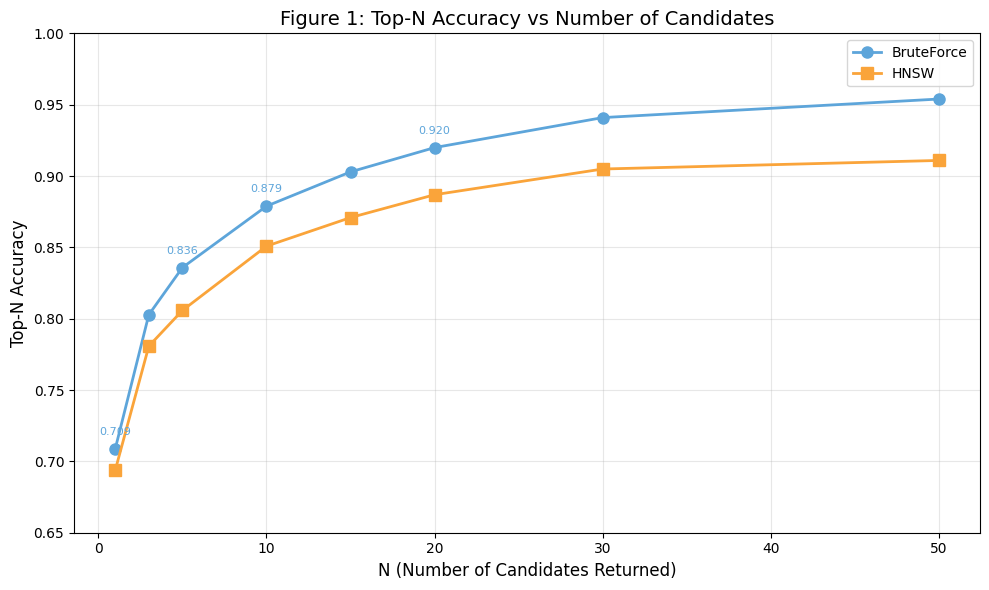

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/topn_accuracy_curve.png


In [6]:
import matplotlib.pyplot as plt

figures_dir = BASE_DIR / "analysis" / "figures"

# Pull the Top-N accuracy values out of the results dicts for plotting
bf_topn = [r["Top-N"] for r in results_by_n]
hnsw_topn = [r["Top-N"] for r in hnsw_results_by_n]

fig, ax = plt.subplots(figsize=(10, 6))

# 'o-' = circles + line for BruteForce 
# 's-' = squares + line for HNSW
ax.plot(n_values, bf_topn, 'o-', label='BruteForce', color='#5DA5DA', linewidth=2, markersize=8)
ax.plot(n_values, hnsw_topn, 's-', label='HNSW', color='#FAA43A', linewidth=2, markersize=8)

ax.set_xlabel('N (Number of Candidates Returned)', fontsize=12)
ax.set_ylabel('Top-N Accuracy', fontsize=12)
ax.set_title('Figure 1: Top-N Accuracy vs Number of Candidates', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.65, 1.0)

# Add annotations for key points
for i, n in enumerate(n_values):
    if n in [1, 5, 10, 20]:
        ax.annotate(f'{bf_topn[i]:.3f}', (n, bf_topn[i]), textcoords="offset points", 
                   xytext=(0, 10), ha='center', fontsize=8, color='#5DA5DA')

plt.tight_layout()
plt.savefig(figures_dir / "topn_accuracy_curve.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'topn_accuracy_curve.png'}")

In [7]:
# Also load CASIA so we can compare it against VGG across different N values
model_casia = Embedding(pretrained="casia-webface", device=pre.device)

# Build CASIA gallery embeddings 
# Same loop structure as VGG
print("Building CASIA gallery embeddings...")
casia_gallery_embs = []
for identity_dir in sorted(GALLERY_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    for img_path in identity_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        emb = model_casia.encode(tensor).astype(np.float32)
        casia_gallery_embs.append(emb)

# Stack into a single matrix -> shape: (2265, 512)
casia_gallery_embs = np.vstack(casia_gallery_embs)

# Build CASIA probe embeddings
print("Building CASIA probe embeddings...")
casia_probe_embs = []
for identity_dir in sorted(PROBE_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    for img_path in identity_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        emb = model_casia.encode(tensor).astype(np.float32)
        casia_probe_embs.append(emb)

# Stack probe embeddings -> shape: (999, 512)
casia_probe_embs = np.vstack(casia_probe_embs)
print(f"CASIA Gallery: {casia_gallery_embs.shape}, Probe: {casia_probe_embs.shape}")

Building CASIA gallery embeddings...
Building CASIA probe embeddings...
CASIA Gallery: (2265, 512), Probe: (999, 512)


In [8]:
# Build a BruteForce index for CASIA 
# Same setup as VGG so results are directly comparable
casia_bf_index = FaissBruteForce(dim=dim, metric="cosine")
casia_bf_index.add_embeddings(casia_gallery_embs, gallery_labels)

# Reuse the same n_values so all models are evaluated at identical N points
casia_results_by_n = []

print("Evaluating CASIA at different values of N...")
for n in n_values:
    top1, topn = evaluate_at_k(casia_bf_index, gallery_labels, casia_probe_embs, probe_labels, k=n)
    casia_results_by_n.append({"N": n, "Top-1": top1, "Top-N": topn})
    print(f"N={n:2d}: Top-1={top1:.4f}, Top-{n}={topn:.4f}")

Evaluating CASIA at different values of N...
N= 1: Top-1=0.3654, Top-1=0.3654
N= 3: Top-1=0.3654, Top-3=0.4685
N= 5: Top-1=0.3654, Top-5=0.5185
N=10: Top-1=0.3654, Top-10=0.5736
N=15: Top-1=0.3654, Top-15=0.6086
N=20: Top-1=0.3654, Top-20=0.6336
N=30: Top-1=0.3654, Top-30=0.6737
N=50: Top-1=0.3654, Top-50=0.7057


In [9]:
print("TOP-N ACCURACY COMPARISON (All Models)")
print(f"{'N':<6} {'VGG BF':>10} {'VGG HNSW':>10} {'CASIA BF':>10}")

for i, n in enumerate(n_values):
    vgg_bf = results_by_n[i]["Top-N"]
    vgg_hnsw = hnsw_results_by_n[i]["Top-N"]
    casia_bf = casia_results_by_n[i]["Top-N"]
    print(f"{n:<6} {vgg_bf:>10.4f} {vgg_hnsw:>10.4f} {casia_bf:>10.4f}")

TOP-N ACCURACY COMPARISON (All Models)
N          VGG BF   VGG HNSW   CASIA BF
1          0.7087     0.6937     0.3654
3          0.8028     0.7808     0.4685
5          0.8358     0.8058     0.5185
10         0.8789     0.8509     0.5736
15         0.9029     0.8709     0.6086
20         0.9199     0.8869     0.6336
30         0.9409     0.9049     0.6737
50         0.9540     0.9109     0.7057


In [10]:
# Bundle up all Task 3 results into one dict for easy loading in later notebooks
task3_results = {
    "n_values": n_values,
    "vgg_bruteforce": results_by_n,
    "vgg_hnsw": hnsw_results_by_n,
    "casia_bruteforce": casia_results_by_n
}

results_path = BASE_DIR / "analysis" / "task3_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(task3_results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task3_results.pkl
